<a href="https://colab.research.google.com/github/melojuharibrahma-bit/Dissertation-/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The libraries are imported and the datasets are loaded in the colab

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
sns.set()

The epidemiology is defined as epi and the mobility data set as mob, these both data sets are read by giving the location of them in the drive .
The output gives the shape of the both data sets and The head of the epidemiology dataset followed by the mobility dataset below.

In [6]:
epi = pd.read_csv('/content/drive/MyDrive/data/epidemiology (3).csv')
mob = pd.read_csv('/content/drive/MyDrive/data/mobility (1).csv')

print("Epidemiology shape:", epi.shape)
print("Mobility shape:", mob.shape)

epi.head()

Epidemiology shape: (12525825, 10)
Mobility shape: (6321226, 8)


,date,location_key,new_confirmed,new_deceased,new_recovered,new_tested,cumulative_confirmed,cumulative_deceased,cumulative_recovered,cumulative_tested
0,2020-01-01,AD,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
1,2020-01-02,AD,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
2,2020-01-03,AD,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
3,2020-01-04,AD,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
4,2020-01-05,AD,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
mob.head()

,date,location_key,mobility_retail_and_recreation,mobility_grocery_and_pharmacy,mobility_parks,mobility_transit_stations,mobility_workplaces,mobility_residential
0,2020-02-15,AE,0.0,4.0,5.0,0.0,2.0,1.0
1,2020-02-16,AE,1.0,4.0,4.0,1.0,2.0,1.0
2,2020-02-17,AE,-1.0,1.0,5.0,1.0,2.0,1.0
3,2020-02-18,AE,-2.0,1.0,5.0,0.0,2.0,1.0
4,2020-02-19,AE,-2.0,0.0,4.0,-1.0,2.0,1.0


Now

In [11]:
epi['date'] = pd.to_datetime(epi['date'])
mob['date'] = pd.to_datetime(mob['date'])

epi = epi.sort_values(['location_key', 'date'])
mob = mob.sort_values(['location_key', 'date'])


print(epi.isnull().sum())
print(mob.isnull().sum())

date                          0
location_key                987
new_confirmed             50025
new_deceased             858687
new_recovered           8545363
new_tested              9331336
cumulative_confirmed     198780
cumulative_deceased     1051000
cumulative_recovered    8534668
cumulative_tested       9512905
dtype: int64
date                                    0
location_key                          941
mobility_retail_and_recreation    2154446
mobility_grocery_and_pharmacy     2385316
mobility_parks                    3381539
mobility_transit_stations         3134225
mobility_workplaces                122718
mobility_residential              2192508
dtype: int64


In [12]:
epi = epi.fillna(method='ffill')
mob = mob.fillna(method='ffill')

epi = epi.dropna()
mob = mob.dropna()

/tmp/ipykernel_49275/2339752931.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  epi = epi.fillna(method='ffill')
/tmp/ipykernel_49275/2339752931.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mob = mob.fillna(method='ffill')


In [13]:
print(epi.isnull().sum())
print(mob.isnull().sum())

date                    0
location_key            0
new_confirmed           0
new_deceased            0
new_recovered           0
new_tested              0
cumulative_confirmed    0
cumulative_deceased     0
cumulative_recovered    0
cumulative_tested       0
dtype: int64
date                              0
location_key                      0
mobility_retail_and_recreation    0
mobility_grocery_and_pharmacy     0
mobility_parks                    0
mobility_transit_stations         0
mobility_workplaces               0
mobility_residential              0
dtype: int64


In [14]:
df = pd.merge(epi, mob, on=['date', 'location_key'], how='inner')

print("Merged shape:", df.shape)
df.head()

Merged shape: (5239858, 16)


,date,location_key,new_confirmed,new_deceased,new_recovered,new_tested,cumulative_confirmed,cumulative_deceased,cumulative_recovered,cumulative_tested,mobility_retail_and_recreation,mobility_grocery_and_pharmacy,mobility_parks,mobility_transit_stations,mobility_workplaces,mobility_residential
0,2020-02-15,AG,0.0,0.0,0.0,325016.0,0.0,0.0,2094.0,994894.0,-6.0,-1.0,-6.0,-1.0,0.0,3.0
1,2020-02-16,AG,0.0,0.0,0.0,325016.0,0.0,0.0,2094.0,994894.0,-7.0,-2.0,0.0,3.0,3.0,3.0
2,2020-02-17,AG,0.0,0.0,0.0,325016.0,0.0,0.0,2094.0,994894.0,0.0,-3.0,3.0,-3.0,0.0,3.0
3,2020-02-18,AG,0.0,0.0,0.0,325016.0,0.0,0.0,2094.0,994894.0,-1.0,-6.0,3.0,5.0,5.0,1.0
4,2020-02-19,AG,0.0,0.0,0.0,325016.0,0.0,0.0,2094.0,994894.0,-2.0,-1.0,1.0,0.0,2.0,1.0


In [15]:
df = df[df['location_key'] == 'US']

print(df.shape)

(941, 16)


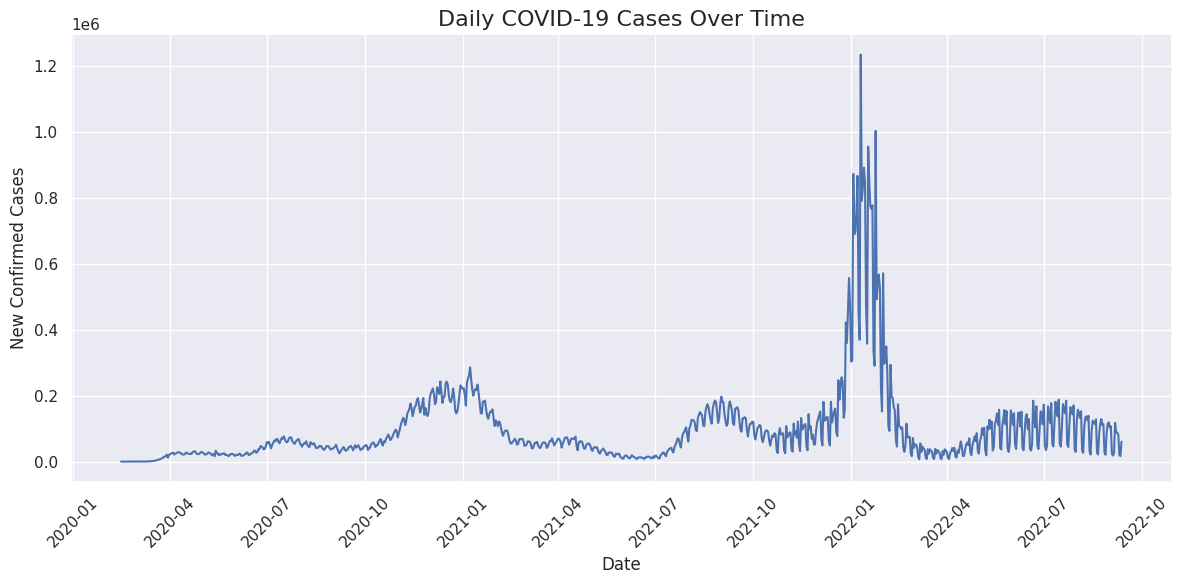

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['new_confirmed'])
plt.title('Daily COVID-19 Cases Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('New Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

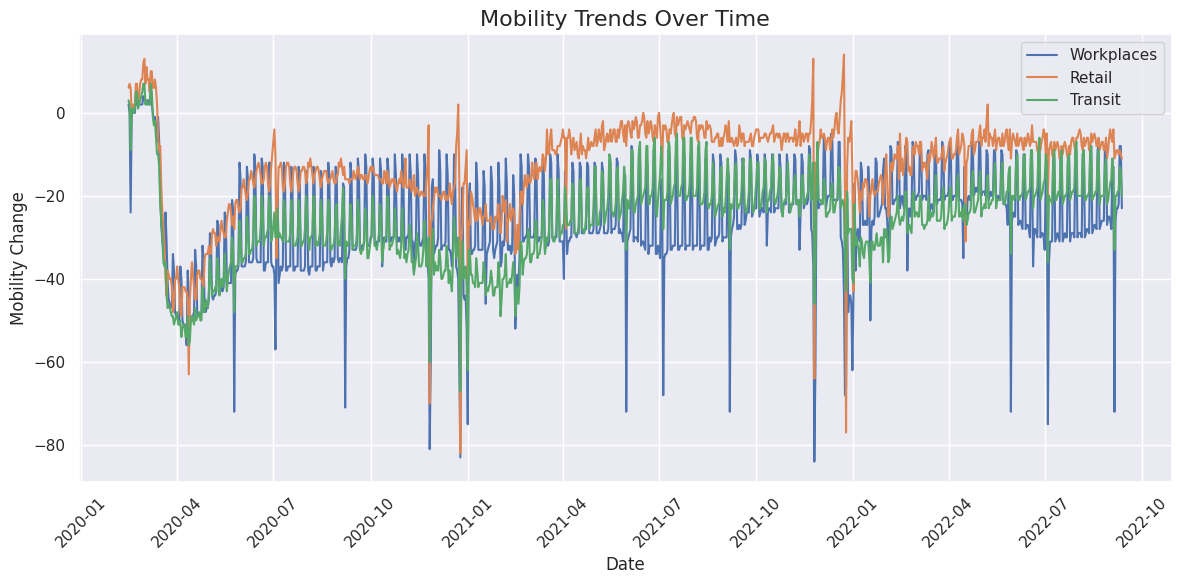

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['mobility_workplaces'], label='Workplaces')
plt.plot(df['date'], df['mobility_retail_and_recreation'], label='Retail')
plt.plot(df['date'], df['mobility_transit_stations'], label='Transit')

plt.title('Mobility Trends Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Mobility Change')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

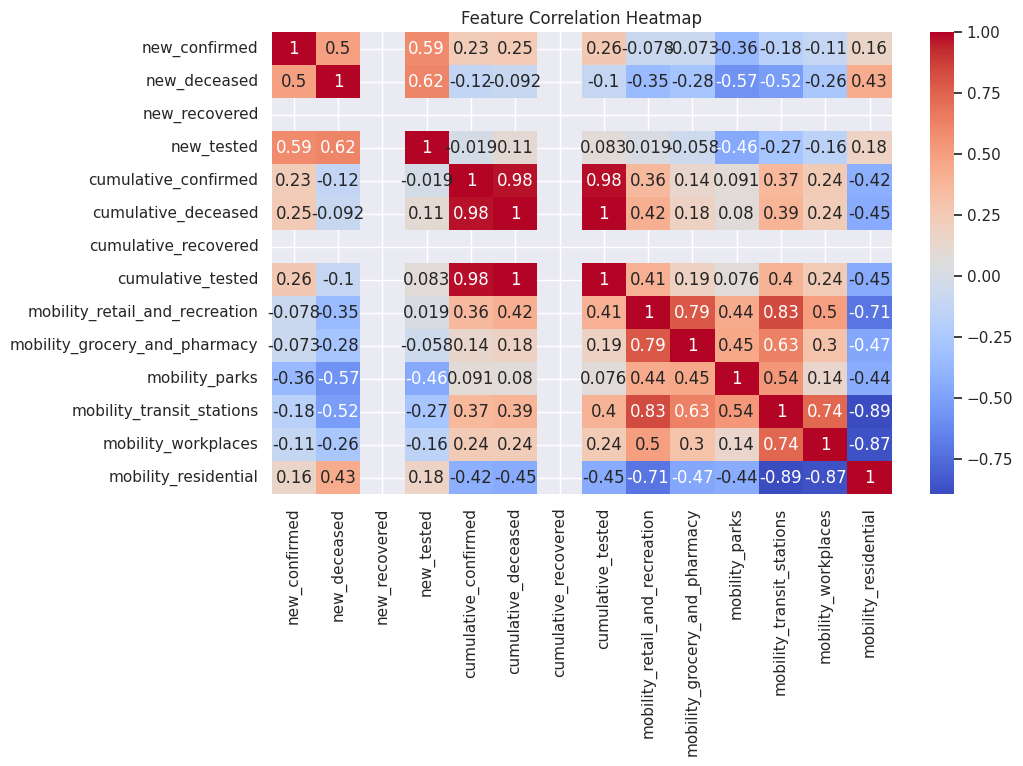

In [18]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

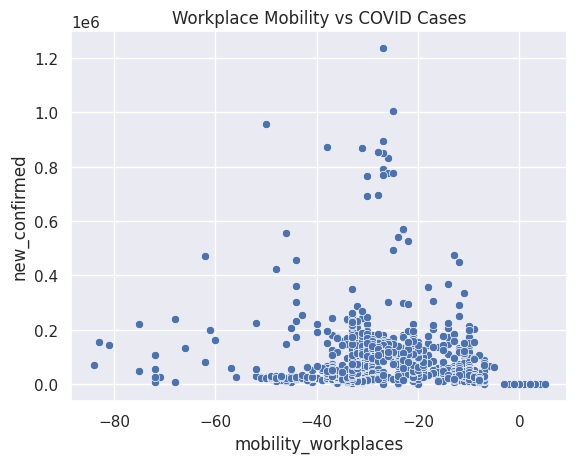

In [19]:
sns.scatterplot(x='mobility_workplaces', y='new_confirmed', data=df)
plt.title('Workplace Mobility vs COVID Cases')
plt.show()

In [20]:
df['lag_1'] = df['new_confirmed'].shift(1)
df['lag_7'] = df['new_confirmed'].shift(7)

df['rolling_mean_7'] = df['new_confirmed'].rolling(window=7).mean()


df = df.dropna()

print(df.head())

              date location_key  new_confirmed  new_deceased  new_recovered  \
3191663 2020-02-22           US            8.0           0.0         3193.0   
3191664 2020-02-23           US            0.0           0.0         3193.0   
3191665 2020-02-24           US            4.0           0.0         3193.0   
3191666 2020-02-25           US            4.0           0.0         3193.0   
3191667 2020-02-26           US            8.0           0.0         3193.0   

         new_tested  cumulative_confirmed  cumulative_deceased  \
3191663     10103.0                  48.0                  0.0   
3191664     10103.0                  48.0                  0.0   
3191665     10103.0                  52.0                  0.0   
3191666     10103.0                  56.0                  0.0   
3191667     10103.0                  64.0                  0.0   

         cumulative_recovered  cumulative_tested  \
3191663              368886.0          2749166.0   
3191664              368

In [21]:
# Target variable
y = df['new_confirmed']
X = df.drop(columns=['date', 'location_key', 'new_confirmed'])

print(X.shape, y.shape)

(934, 16) (934,)


In [22]:
# 80% train, 20% test
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (747, 16)
Test size: (187, 16)


In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Linear Regression -> MAE:", mae_lr, "RMSE:", rmse_lr)
print("Random Forest -> MAE:", mae_rf, "RMSE:", rmse_rf)

Linear Regression -> MAE: 80158.61457491393 RMSE: 83799.64540416632
Random Forest -> MAE: 18518.064385026733 RMSE: 24807.06261483399


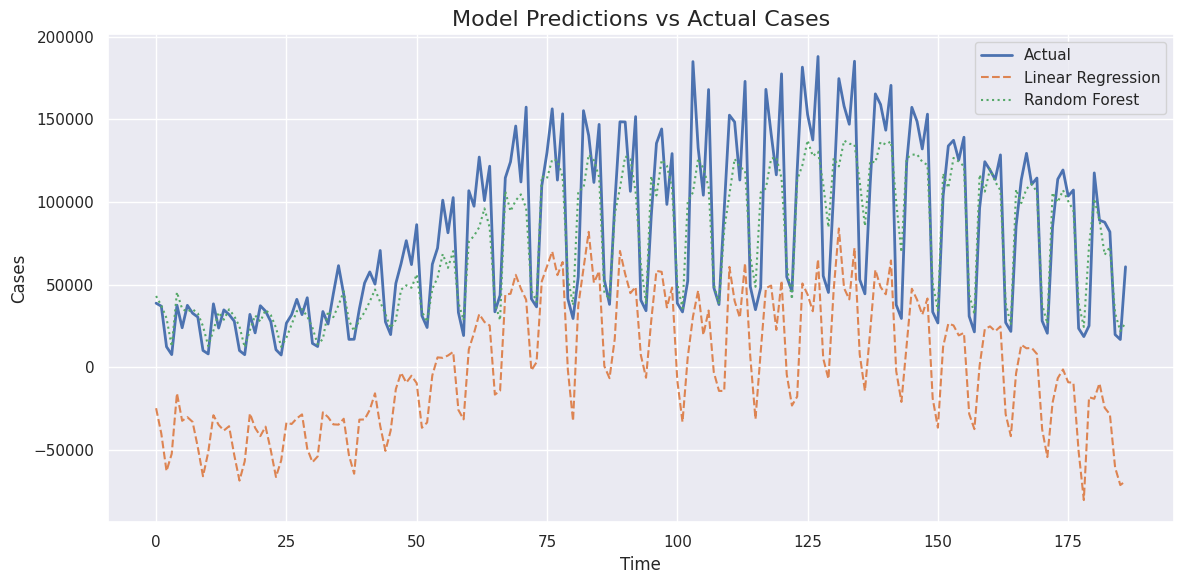

In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred_lr, label='Linear Regression', linestyle='dashed')
plt.plot(y_pred_rf, label='Random Forest', linestyle='dotted')

plt.title('Model Predictions vs Actual Cases', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
importances = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp)

rolling_mean_7                    0.469205
lag_7                             0.235457
lag_1                             0.187664
new_tested                        0.048476
mobility_residential              0.016616
mobility_grocery_and_pharmacy     0.006838
mobility_workplaces               0.006561
new_deceased                      0.005806
cumulative_deceased               0.005311
cumulative_tested                 0.004932
mobility_parks                    0.004534
cumulative_confirmed              0.004196
mobility_retail_and_recreation    0.002222
mobility_transit_stations         0.002183
cumulative_recovered              0.000000
new_recovered                     0.000000
dtype: float64


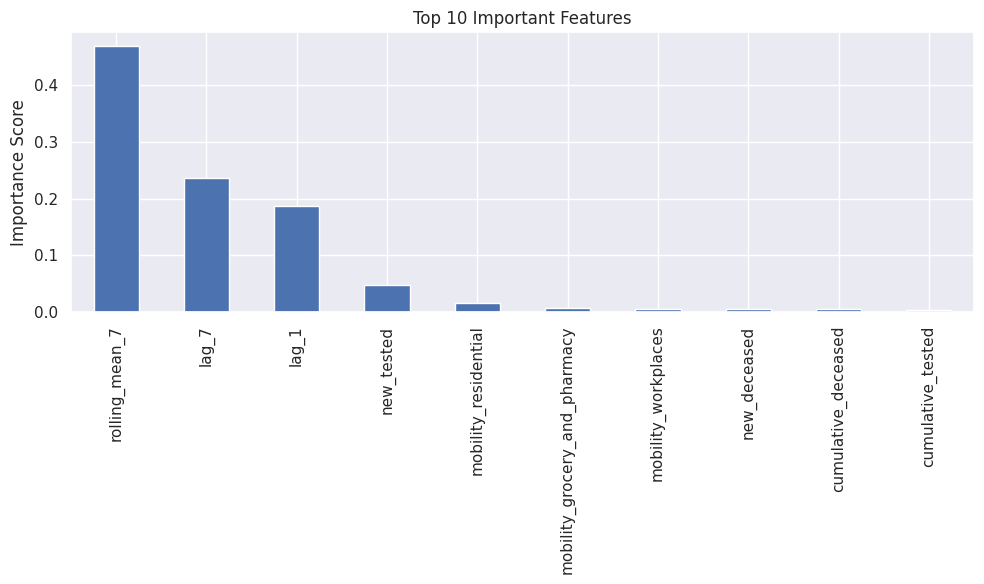

In [28]:
plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

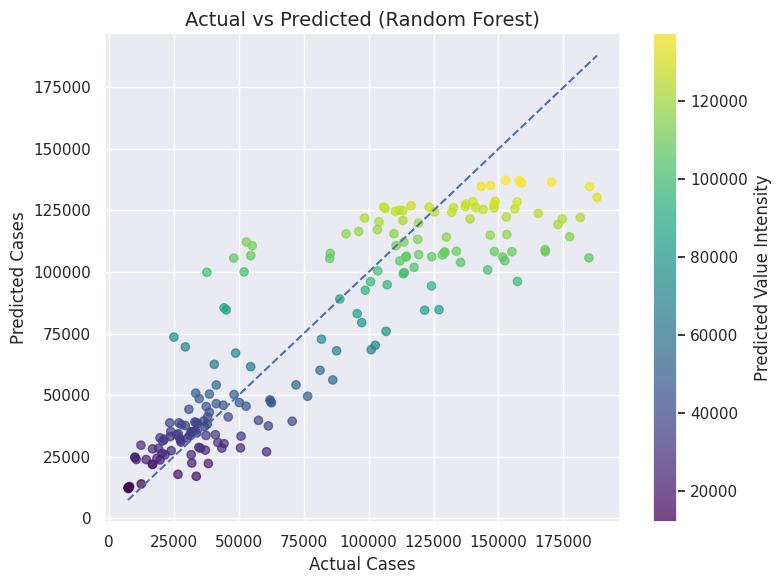

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, c=y_pred_rf, cmap='viridis', alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel('Actual Cases', fontsize=12)
plt.ylabel('Predicted Cases', fontsize=12)
plt.title('Actual vs Predicted (Random Forest)', fontsize=14)

plt.colorbar(label='Predicted Value Intensity')

plt.tight_layout()
plt.show()